In [1]:
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
import numpy as np
import healpy as hp

In [3]:
NSIDE = 32
print(
    "Approximate resolution at NSIDE {} is {:.2} deg".format(
        NSIDE, hp.nside2resol(NSIDE, arcmin=True) / 60
    )
)

Approximate resolution at NSIDE 32 is 1.8 deg


In [4]:
NPIX = hp.nside2npix(NSIDE) #12*NSIDE^2
print(NPIX)

12288


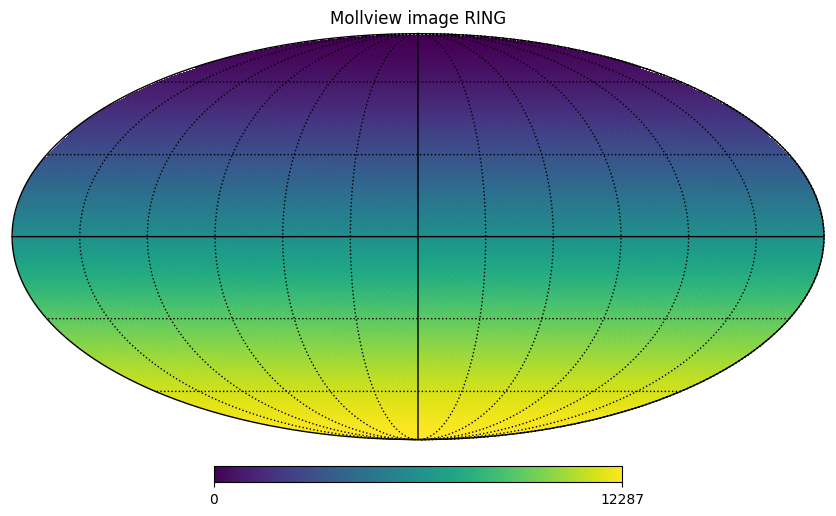

In [5]:
m = np.arange(NPIX)
hp.mollview(m, nest=False, title="Mollview image RING")
hp.graticule()

In [6]:
vec = hp.ang2vec(np.pi / 2, np.pi * 3 / 4) #what does this even mean? how i jump from 2D in 3D? What is the reference frame?

print(vec)

[-7.07106781e-01  7.07106781e-01  6.12323400e-17]


In [7]:
ipix_disc = hp.query_disc(nside=32, vec=vec, radius=np.radians(10), inclusive=False) #why radius in radiants? what is inclusive?
ipix_disc

array([5103, 5104, 5231, 5232, 5233, 5358, 5359, 5360, 5361, 5486, 5487,
       5488, 5489, 5490, 5613, 5614, 5615, 5616, 5617, 5618, 5741, 5742,
       5743, 5744, 5745, 5746, 5747, 5869, 5870, 5871, 5872, 5873, 5874,
       5997, 5998, 5999, 6000, 6001, 6002, 6003, 6124, 6125, 6126, 6127,
       6128, 6129, 6130, 6131, 6253, 6254, 6255, 6256, 6257, 6258, 6259,
       6381, 6382, 6383, 6384, 6385, 6386, 6509, 6510, 6511, 6512, 6513,
       6514, 6515, 6637, 6638, 6639, 6640, 6641, 6642, 6766, 6767, 6768,
       6769, 6770, 6894, 6895, 6896, 6897, 7023, 7024, 7025, 7151, 7152])

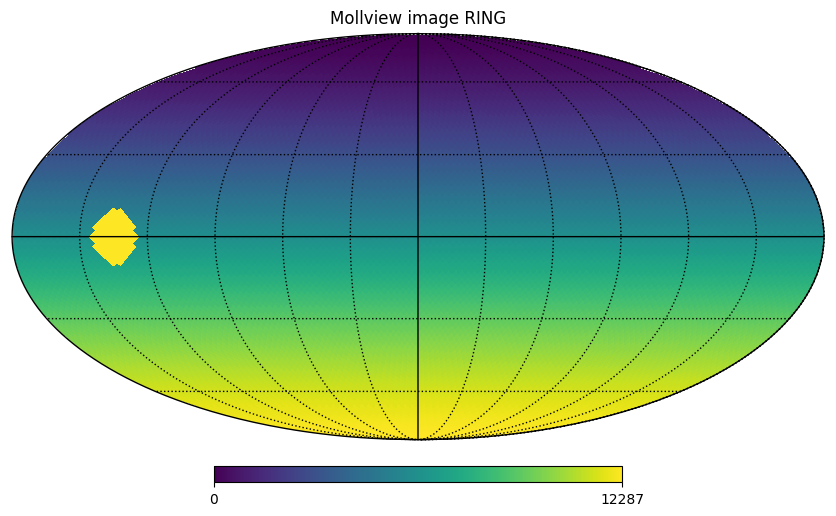

In [8]:
m = np.arange(NPIX)
m[ipix_disc] = m.max()
hp.mollview(m, title="Mollview image RING") #why nest=True ruined everiting?
hp.graticule()

In [9]:
theta, phi = np.degrees(hp.pix2ang(nside=32, ipix=[0, 1, 2, 3, 4]))
theta #5D????

array([1.46197116, 1.46197116, 1.46197116, 1.46197116, 2.92418036])

In [10]:
phi

array([ 45. , 135. , 225. , 315. ,  22.5])

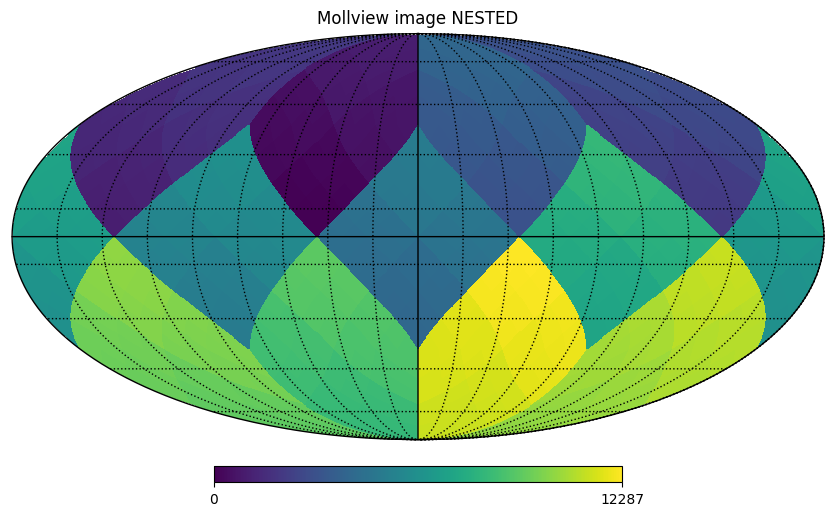

In [11]:
m = np.arange(NPIX)
hp.mollview(m, nest=True, title="Mollview image NESTED")
hp.graticule(True)

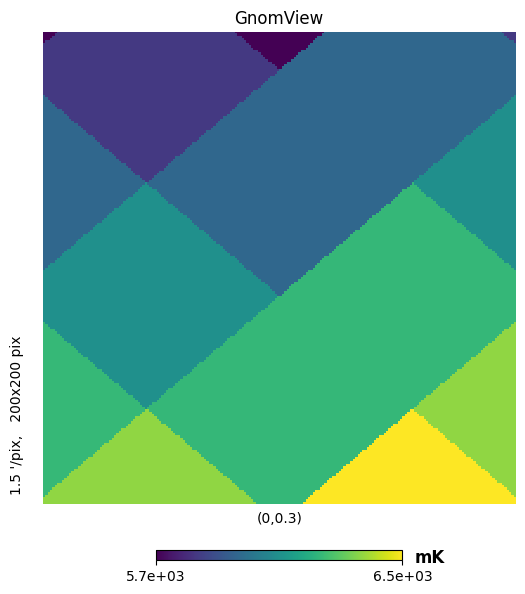

In [12]:
hp.gnomview(m, nest=False, rot=[0, 0.3], title="GnomView", unit="mK", format="%.2g") #format?

In [13]:
wmap_map_I = hp.read_map("wmap_band_iqumap_r9_7yr_W_v4.fits")


In [14]:
hp.write_map("my_map.fits", wmap_map_I, overwrite=True)


setting the output map dtype to [dtype('>f4')]


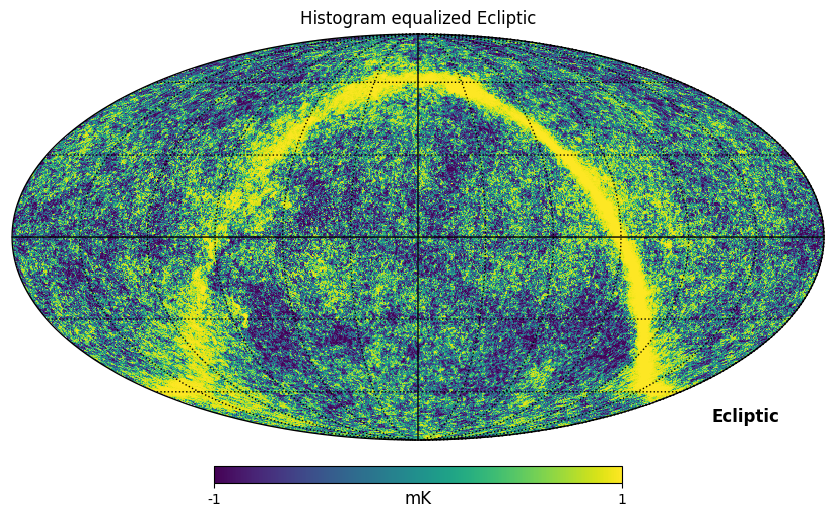

In [15]:
hp.mollview(
    wmap_map_I,
    coord=["G", "E"],
    title="Histogram equalized Ecliptic",
    unit="mK",
    norm="hist",
    min=-1,
    max=1,
)
hp.graticule()

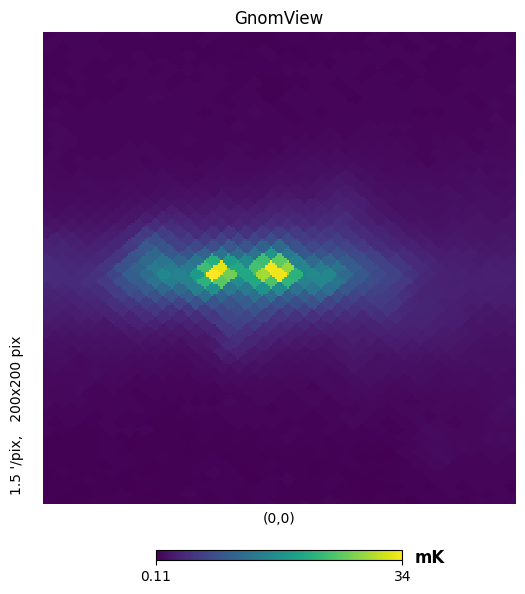

In [16]:
hp.gnomview(wmap_map_I, rot=[0,0], title="GnomView", unit="mK", format="%.2g") #how i choose where to set the rot?

In [17]:
import os
print(f"Cartella attuale: {os.getcwd()}")
print("File presenti:")
print(os.listdir('.'))

Cartella attuale: /home/tpc/astro_projects
File presenti:
['.ipynb_checkpoints', 'TEST.ipynb', '.git', 'healpy_env', 'my_map.fits', 'wmap_temperature_analysis_mask_r9_7yr_v4.fits', 'Untitled.ipynb', '.gitignore', 'wmap_band_iqumap_r9_7yr_W_v4.fits']


In [18]:
!wget -c http://lambda.gsfc.nasa.gov/data/map/dr4/ancillary/masks/wmap_temperature_analysis_mask_r9_7yr_v4.fits

URL transformed to HTTPS due to an HSTS policy
--2026-04-28 15:10:52--  https://lambda.gsfc.nasa.gov/data/map/dr4/ancillary/masks/wmap_temperature_analysis_mask_r9_7yr_v4.fits
Resolving lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)... 129.164.179.68, 2001:4d0:2310:150::68
Connecting to lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)|129.164.179.68|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [19]:
mask = hp.read_map("wmap_temperature_analysis_mask_r9_7yr_v4.fits").astype(np.bool_)
wmap_map_I_masked = hp.ma(wmap_map_I)
wmap_map_I_masked.mask = np.logical_not(mask)

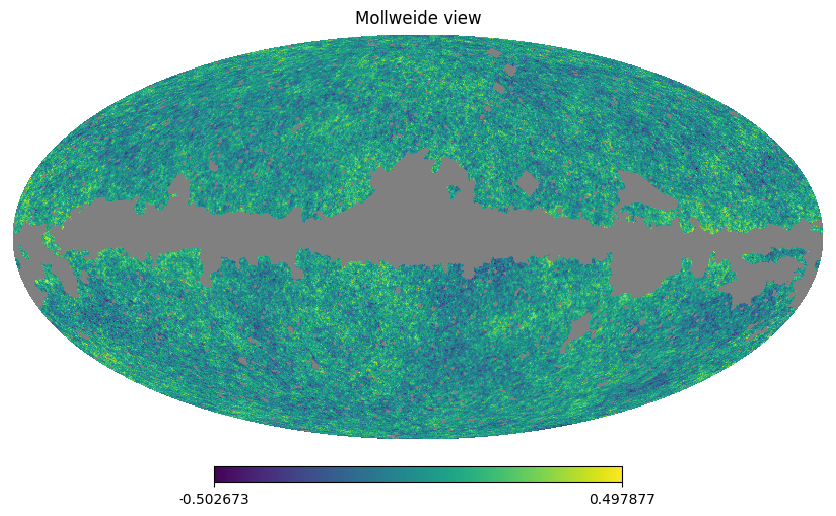

In [20]:
hp.mollview(wmap_map_I_masked.filled())

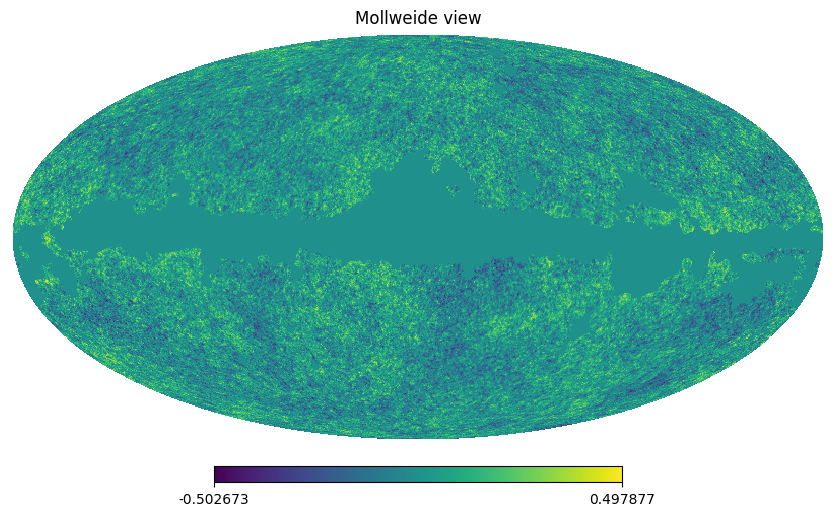

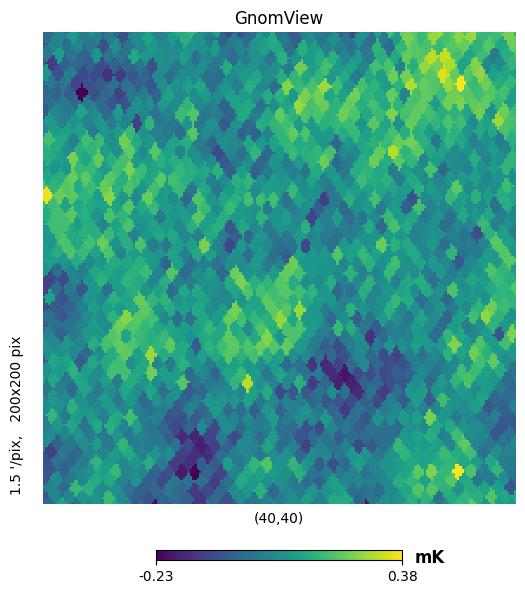

In [36]:
hp.mollview(wmap_map_I_masked.filled(False))
hp.gnomview(wmap_map_I_masked, rot=[40,40], title="GnomView", unit="mK", format="%.2g") #how i choose where to set the rot?

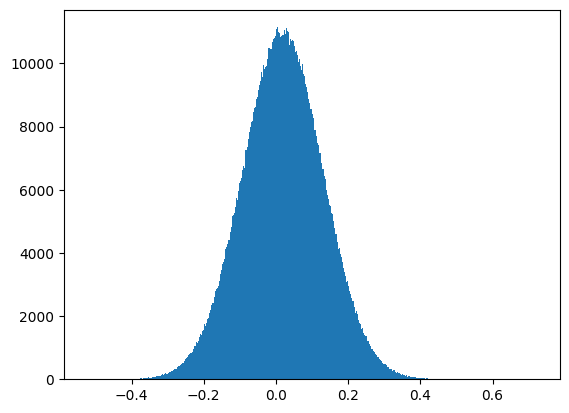

In [23]:
plt.hist(wmap_map_I_masked.compressed(), bins=1000); #what does he plot?

In [31]:
LMAX = 1024
cl = hp.anafast(wmap_map_I_masked.filled(), lmax=LMAX)
ell = np.arange(len(cl))

<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_820/1438154512.py:3: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel("$\ell$")
/tmp/ipykernel_820/1438154512.py:4: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel("$\ell(\ell+1)C_{\ell}$")


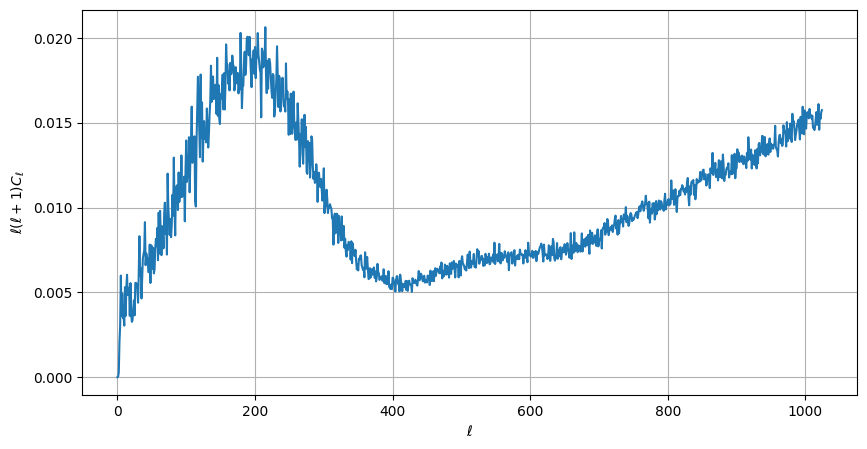

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(ell, ell * (ell + 1) * cl)
plt.xlabel("$\ell$")
plt.ylabel("$\ell(\ell+1)C_{\ell}$")
plt.grid()
hp.write_cl("cl.fits", cl, overwrite=True)

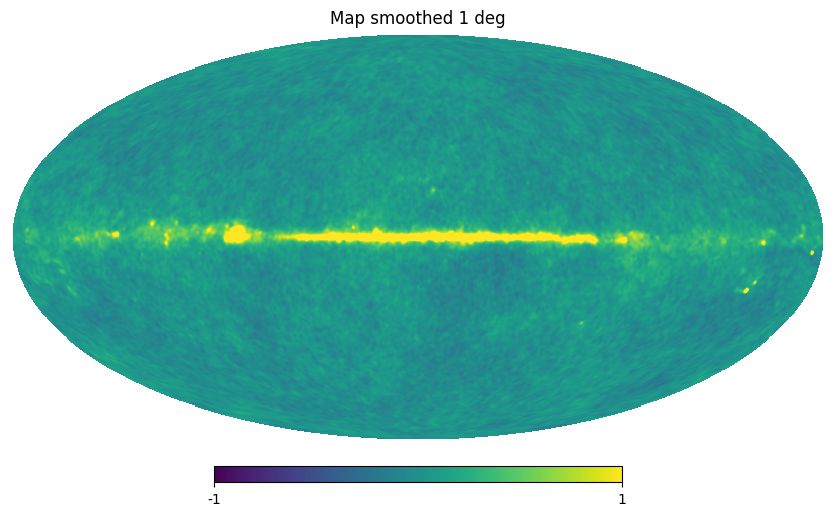

In [33]:
wmap_map_I_smoothed = hp.smoothing(wmap_map_I, fwhm=np.radians(1.))
hp.mollview(wmap_map_I_smoothed, min=-1, max=1, title="Map smoothed 1 deg")